# Univariate and Bivariate Analysis of Application (Demografic and Family) Data
- table - application_train.csv
---

__Client's demografic and family info__:
- `CODE_GENDER` - Gender of the client
- `DAYS_BIRTH` - Client's age in days at the time of application,time only relative to the application
- `CNT_CHILDREN` - Number of children the client has (useful for calculating income/people in household)
- `CNT_FAM_MEMBERS` - How many family members does client have
- `NAME_FAMILY_STATUS` - Family status of the client
- `NAME_EDUCATION_TYPE` - Level of highest education the client achieved
- `OCCUPATION_TYPE` - What kind of occupation does the client have
- `ORGANIZATION_TYPE` - Type of organization where client works
- `REG_REGION_NOT_LIVE_REGION` - Flag if client's permanent address does not match contact address (1=different, 0=same, at region level)
- `REG_REGION_NOT_WORK_REGION` - Flag if client's permanent address does not match work address (1=different, 0=same, at region level)
- `LIVE_REGION_NOT_WORK_REGION` - Flag if client's contact address does not match work address (1=different, 0=same, at region level)
- `REG_CITY_NOT_LIVE_CITY` - Flag if client's permanent address does not match contact address (1=different, 0=same, at city level)
- `REG_CITY_NOT_WORK_CITY` - Flag if client's permanent address does not match work address (1=different, 0=same, at city level)
- `LIVE_CITY_NOT_WORK_CITY` - Flag if client's contact address does not match work address (1=different, 0=same, at city level)

## 0. Data and libraries

In [1]:
import pandas as pd
import numpy as np

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
SRC_PATH = PROJECT_ROOT / 'src'

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from eda_module import (
    plot_quantitative_distribution, plot_categorical_distribution, plot_binary_distribution, 
    plot_binary_vs_binary, plot_categorical_distribution, plot_quantitative_vs_binary,
    plot_categorical_vs_binary
)
from preprocess_module import (
    create_imputed_quantitative_features, filter_high_nans_cols, drop_obs_with_nans_in_low_nan_cols,
    trim_quantitative_var, cap_quantitative_var, categorical_target_summary
)

In [2]:
app_df = pd.read_csv(r"..\data\raw\application_train.csv")
print(f"Shape of app_df: {app_df.shape}")
app_df.head(10)

Shape of app_df: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
5,100008,0,Cash loans,M,N,Y,0,99000.0,490495.5,27517.5,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,1.0
6,100009,0,Cash loans,F,Y,Y,1,171000.0,1560726.0,41301.0,...,0,0,0,0,0.0,0.0,0.0,1.0,1.0,2.0
7,100010,0,Cash loans,M,Y,Y,0,360000.0,1530000.0,42075.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
8,100011,0,Cash loans,F,N,Y,0,112500.0,1019610.0,33826.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
9,100012,0,Revolving loans,M,N,Y,0,135000.0,405000.0,20250.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


## 1. CODE_GENDER
Gender of the client

In [3]:
app_df['CODE_GENDER'].value_counts()

CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

In [4]:
app_df['CODE_GENDER'] = np.where(
    app_df['CODE_GENDER'].isin(['F','M']),
    app_df['CODE_GENDER'],
    np.nan
)

app_df['CODE_GENDER'].value_counts()

CODE_GENDER
F    202448
M    105059
Name: count, dtype: int64

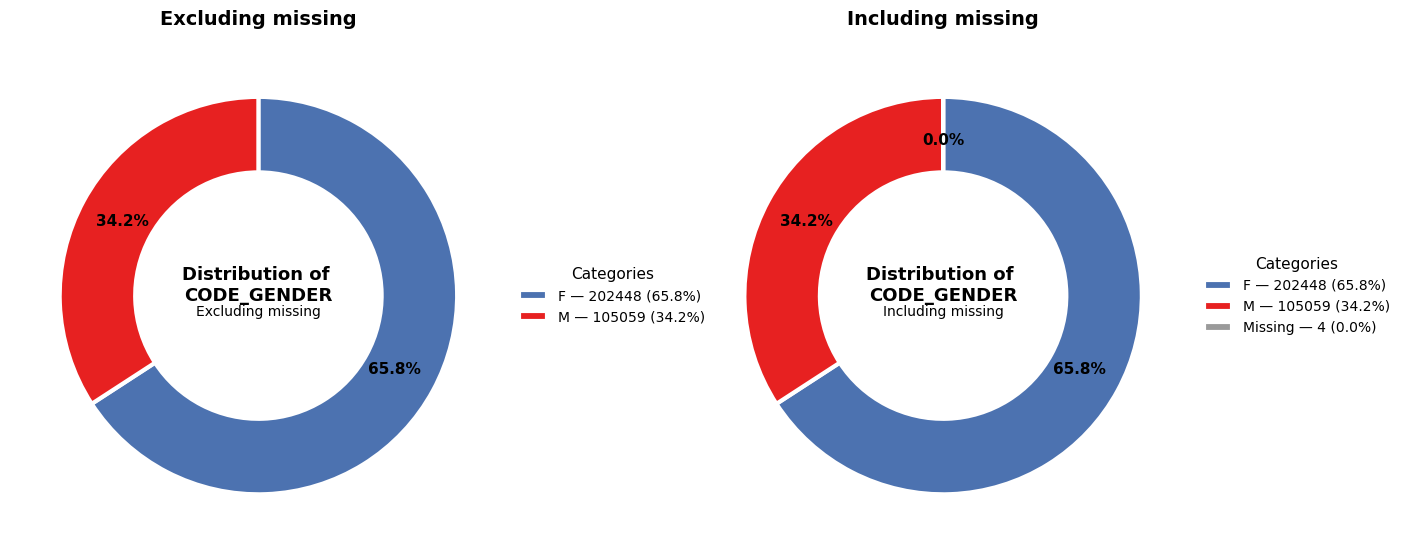

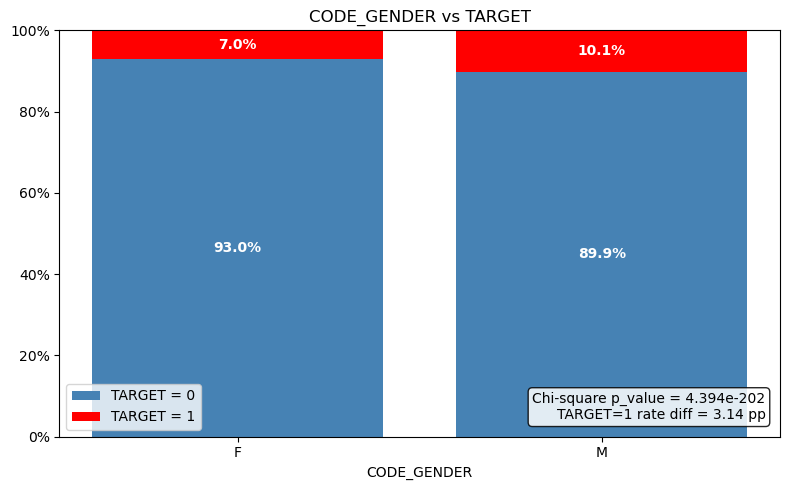

In [5]:
plot_binary_distribution(df=app_df, binary_var='CODE_GENDER')
plot_binary_vs_binary(df=app_df, binary_var='CODE_GENDER', target_var='TARGET')

Males have significanlty higer default reate. The variable should be used in modeling. Observations with missing values (4) can be dropped 

## 2. DAYS_BIRTH
Client's age in days at the time of application,time only relative to the application

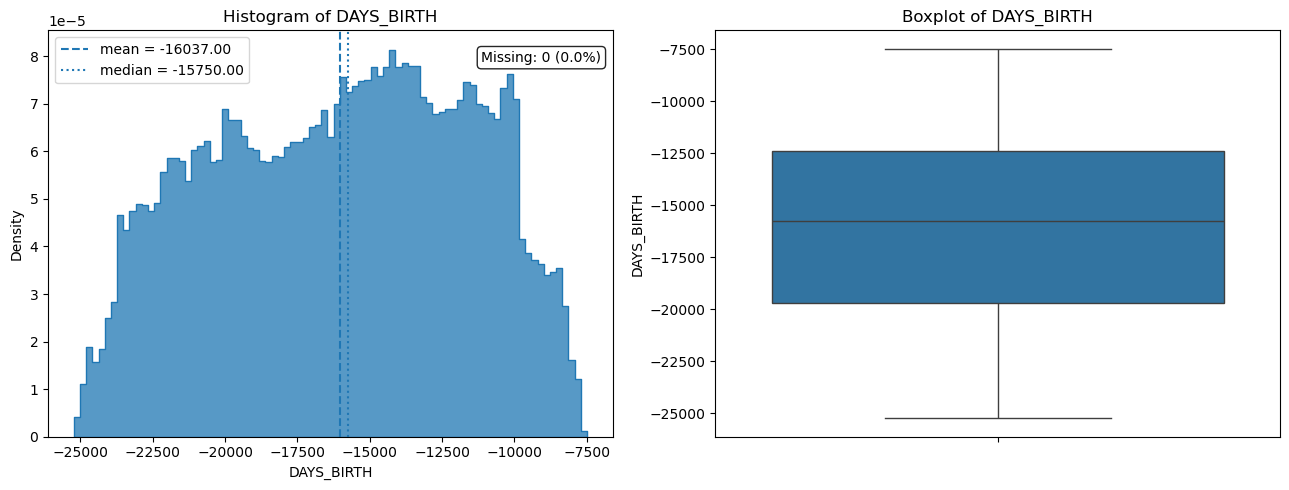

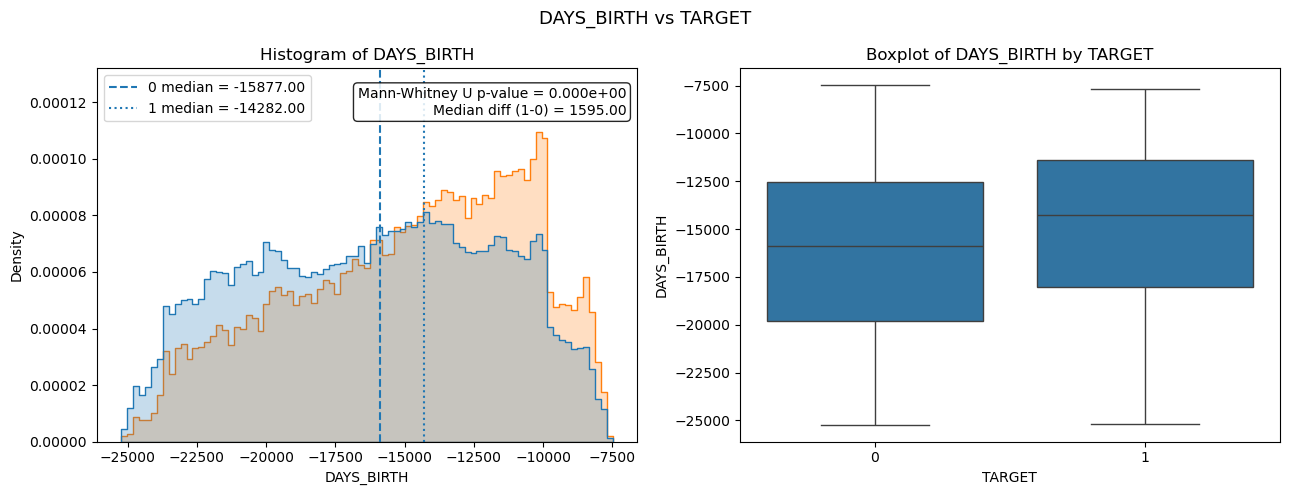

In [6]:
plot_quantitative_distribution(df=app_df, quant_var='DAYS_BIRTH')
plot_quantitative_vs_binary(df=app_df, quant_var='DAYS_BIRTH', binary_var='TARGET')

People who default are rather younger, so this variable shoul dbe used in modeling.

## 3. CNT_CHILDREN
Number of children the client has

In [7]:
app_df['CNT_CHILDREN'].value_counts()

CNT_CHILDREN
0     215371
1      61119
2      26749
3       3717
4        429
5         84
6         21
7          7
14         3
9          2
8          2
10         2
12         2
19         2
11         1
Name: count, dtype: int64

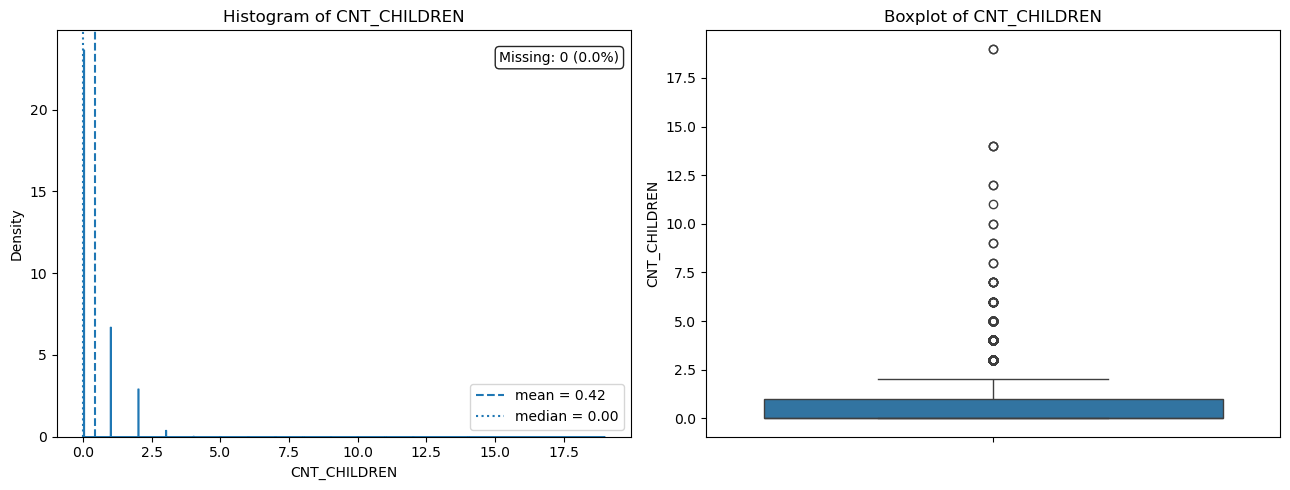

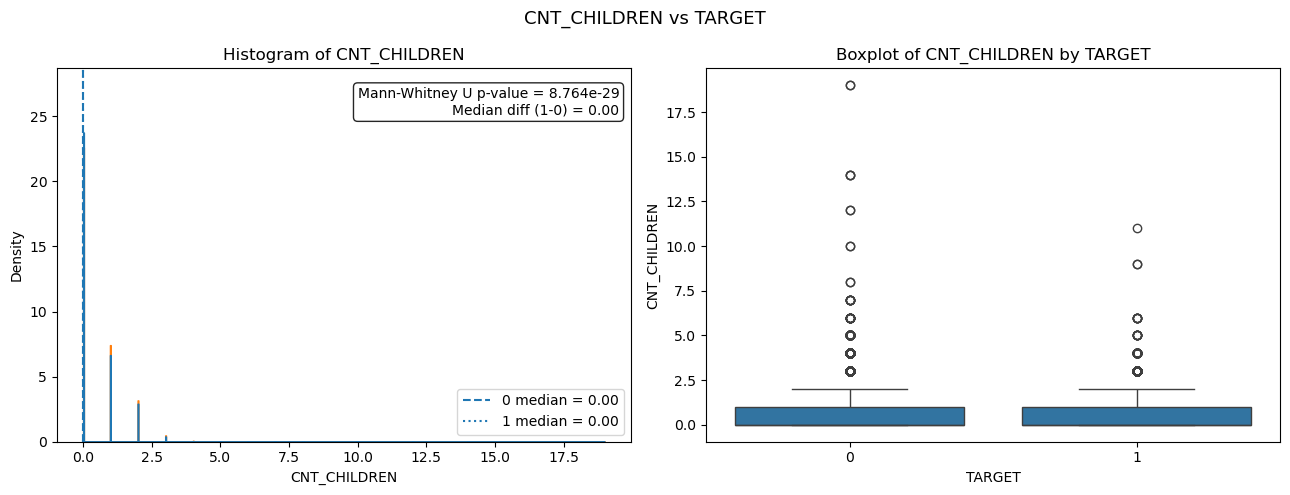

In [8]:
plot_quantitative_distribution(df=app_df, quant_var='CNT_CHILDREN')
plot_quantitative_vs_binary(df=app_df, quant_var='CNT_CHILDREN', binary_var='TARGET')

In [9]:
app_df['CNT_CHILDREN_grouped'] = np.where(
    app_df['CNT_CHILDREN'].isin([0,1,2,3]),
    app_df['CNT_CHILDREN'].astype(str),
    '> 3'
)

app_df['CNT_CHILDREN_grouped'].value_counts()

CNT_CHILDREN_grouped
0      215371
1       61119
2       26749
3        3717
> 3       555
Name: count, dtype: int64

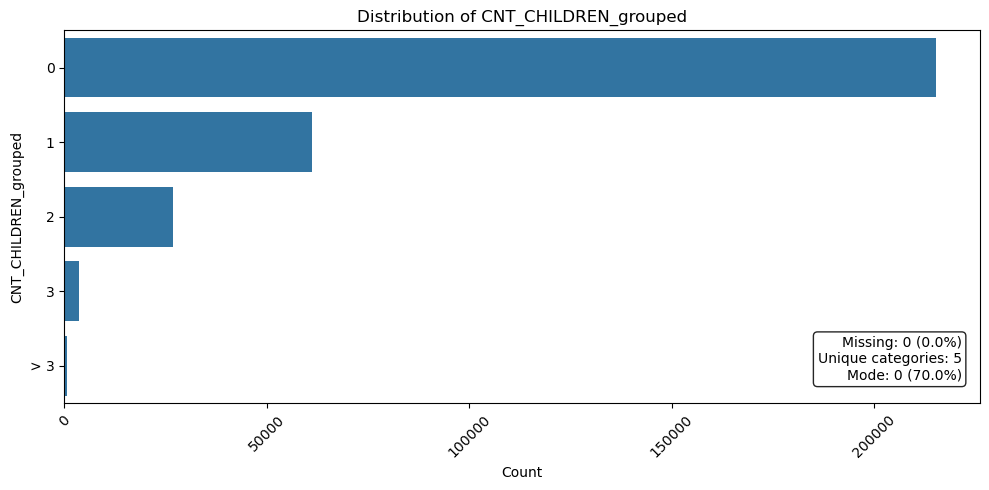

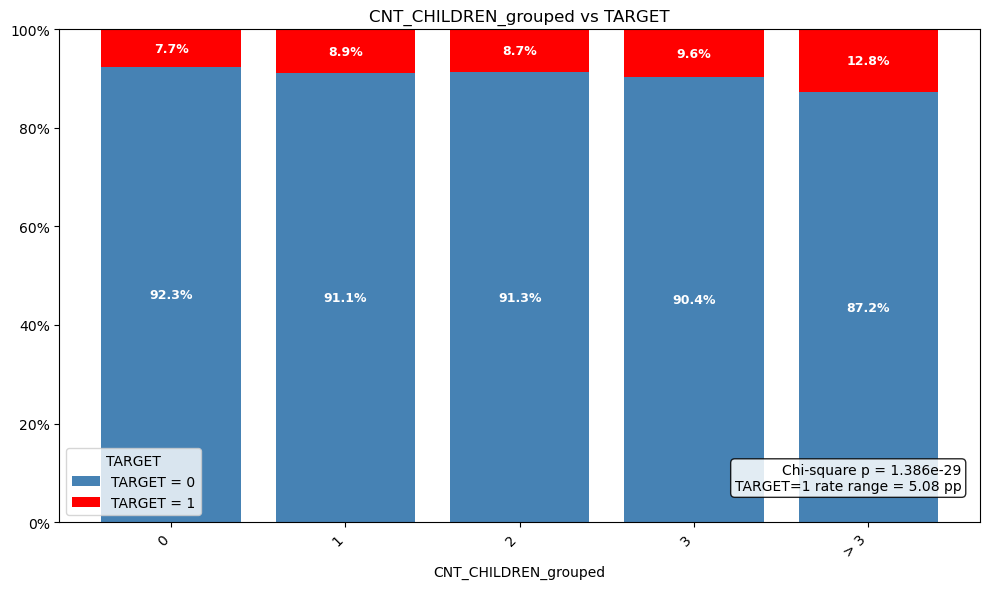

In [10]:
plot_categorical_distribution(df=app_df, cat_var='CNT_CHILDREN_grouped')
plot_categorical_vs_binary(df=app_df, cat_var='CNT_CHILDREN_grouped', target_var='TARGET')

It looks like risk increases with number of children. `CNT_CHILDREN_grouped` should be used in modeling.

## 4. CNT_FAM_MEMBERS
How many family members does client have

In [11]:
app_df['CNT_FAM_MEMBERS'].value_counts()

CNT_FAM_MEMBERS
2.0     158357
1.0      67847
3.0      52601
4.0      24697
5.0       3478
6.0        408
7.0         81
8.0         20
9.0          6
10.0         3
14.0         2
12.0         2
20.0         2
16.0         2
13.0         1
15.0         1
11.0         1
Name: count, dtype: int64

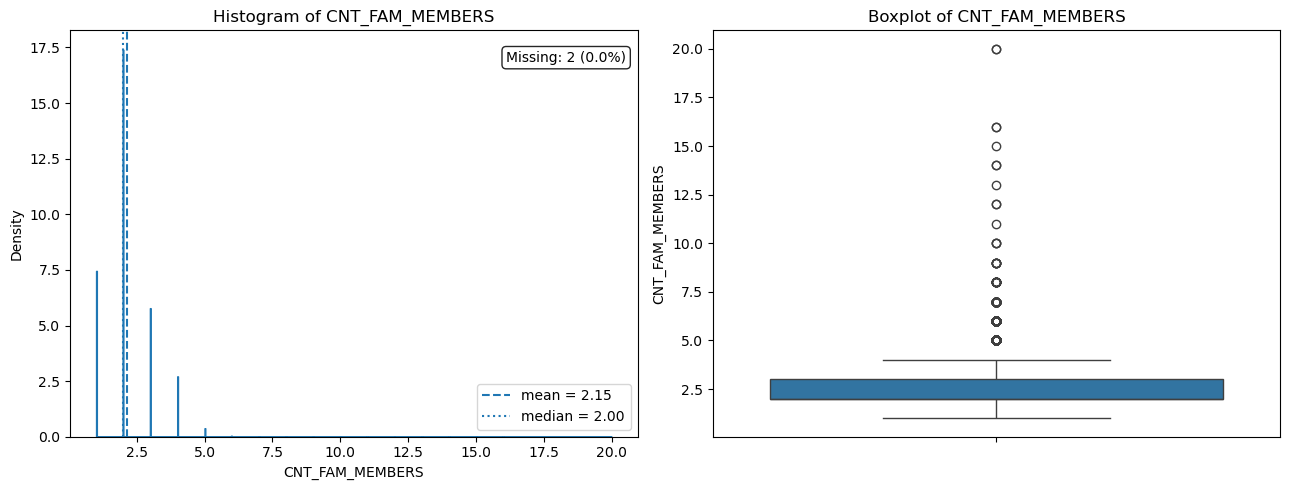

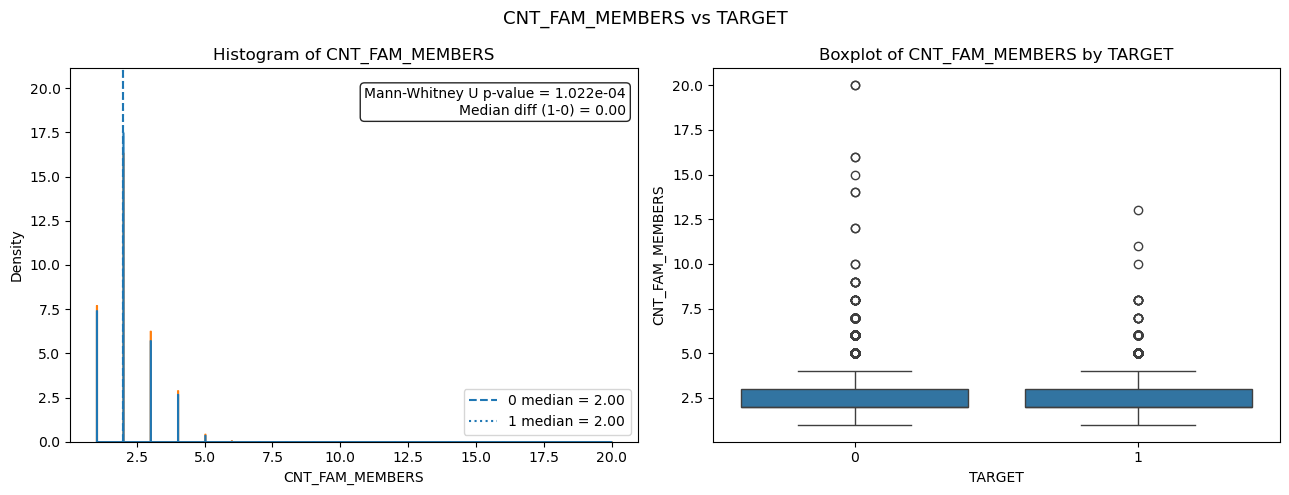

In [12]:
plot_quantitative_distribution(df=app_df, quant_var='CNT_FAM_MEMBERS')
plot_quantitative_vs_binary(df=app_df, quant_var='CNT_FAM_MEMBERS', binary_var='TARGET')

In [13]:
app_df['CNT_FAM_MEMBERS_grouped'] = np.where(
    app_df['CNT_FAM_MEMBERS'].isin([1,2,3,4,5]),
    app_df['CNT_FAM_MEMBERS'].astype(str),
    '> 5'
)
app_df['CNT_FAM_MEMBERS_grouped'].value_counts()

CNT_FAM_MEMBERS_grouped
2.0    158357
1.0     67847
3.0     52601
4.0     24697
5.0      3478
> 5       531
Name: count, dtype: int64

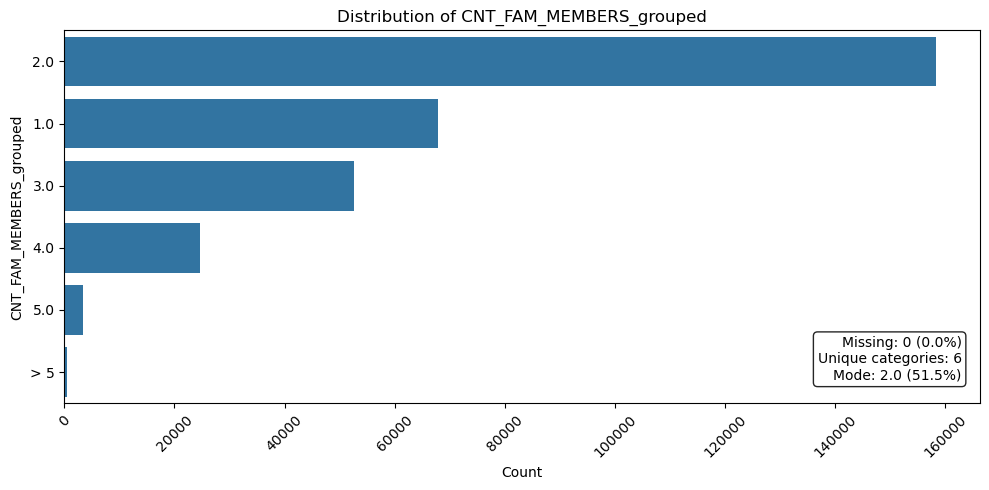

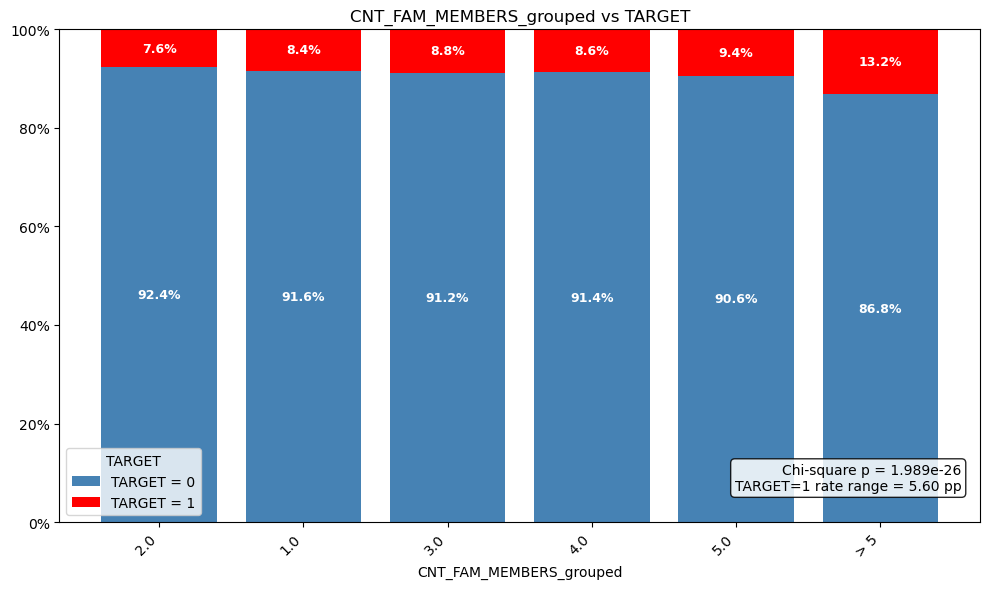

In [14]:
plot_categorical_distribution(df=app_df, cat_var='CNT_FAM_MEMBERS_grouped')
plot_categorical_vs_binary(df=app_df, cat_var='CNT_FAM_MEMBERS_grouped', target_var='TARGET')

Default share increases as the `CNT_FAM_MEMBERS` increases. `CNT_FAM_MEMBERS_grouped` should be used in modeling.

## 5. NAME_FAMILY_STATUS
Family status of the client

In [15]:
app_df['NAME_FAMILY_STATUS'].value_counts()

NAME_FAMILY_STATUS
Married                 196432
Single / not married     45444
Civil marriage           29775
Separated                19770
Widow                    16088
Unknown                      2
Name: count, dtype: int64

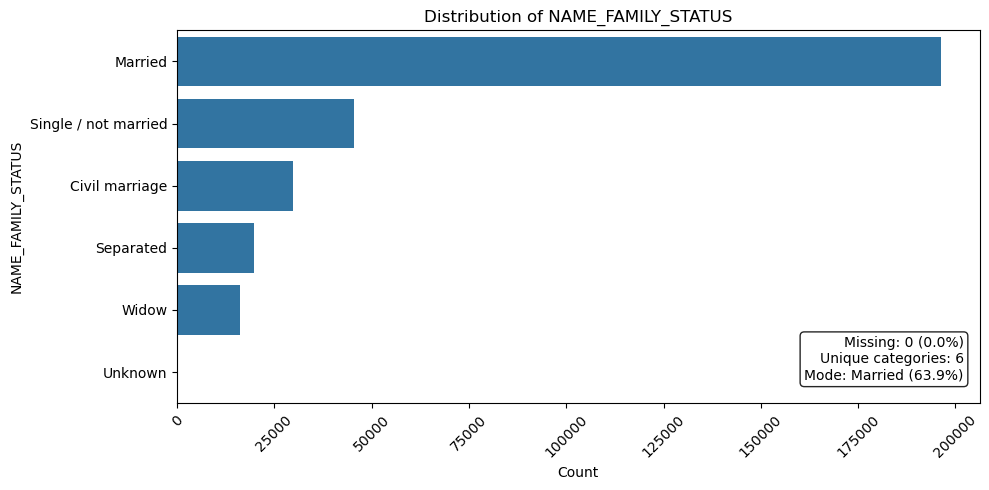

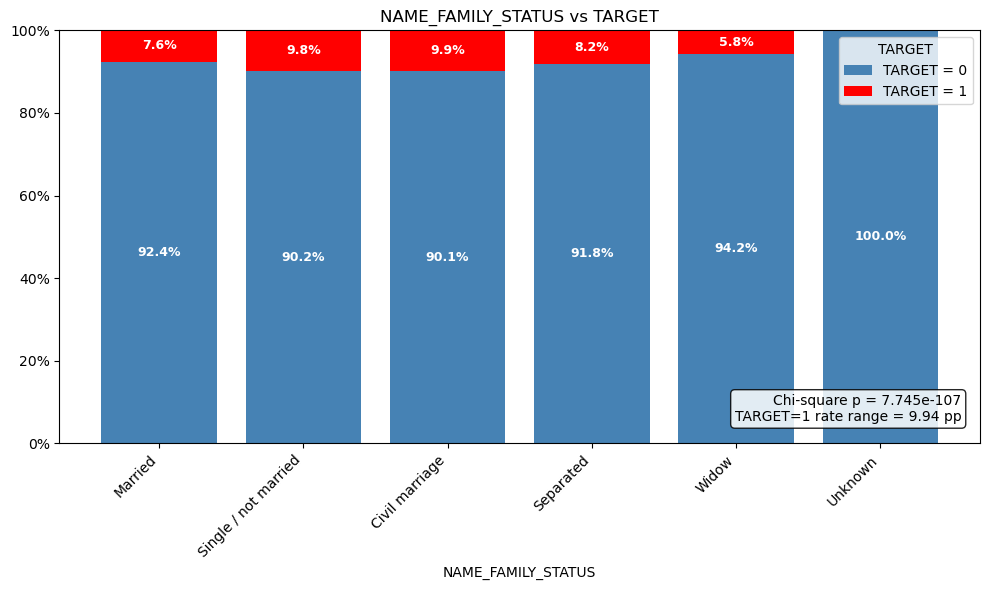

In [16]:
plot_categorical_distribution(df=app_df, cat_var='NAME_FAMILY_STATUS')
plot_categorical_vs_binary(df=app_df, cat_var='NAME_FAMILY_STATUS', target_var='TARGET')

`Widow` and `Unknown` will be merged since they have lowest default rate.

In [17]:
app_df['NAME_FAMILY_STATUS_grouped'] = np.where(
    app_df['NAME_FAMILY_STATUS'].isin(['Widow', 'Unknown']),
    'Widow / Unknown',
    app_df['NAME_FAMILY_STATUS']
)
app_df['NAME_FAMILY_STATUS_grouped'].value_counts()

NAME_FAMILY_STATUS_grouped
Married                 196432
Single / not married     45444
Civil marriage           29775
Separated                19770
Widow / Unknown          16090
Name: count, dtype: int64

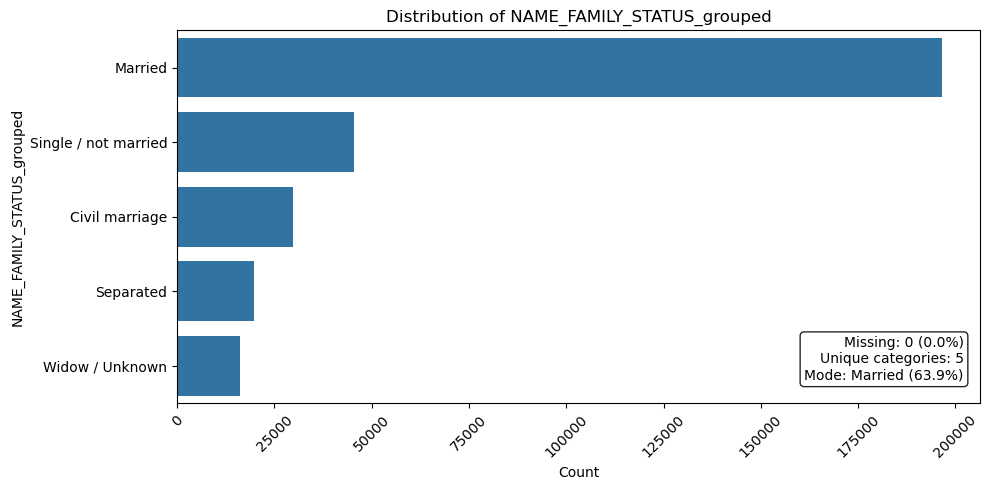

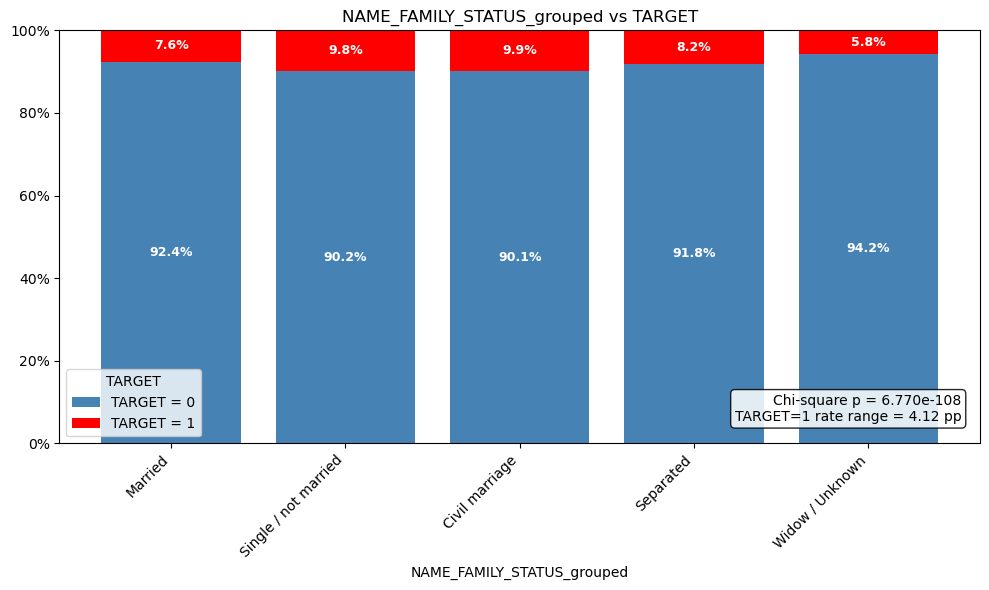

In [18]:
plot_categorical_distribution(df=app_df, cat_var='NAME_FAMILY_STATUS_grouped')
plot_categorical_vs_binary(df=app_df, cat_var='NAME_FAMILY_STATUS_grouped', target_var='TARGET')

Risk share differs accross categories, the variable will be used in modeling.

## 6. NAME_EDUCATION_TYPE
Level of highest education the client achieved

In [19]:
app_df['NAME_EDUCATION_TYPE'].value_counts()

NAME_EDUCATION_TYPE
Secondary / secondary special    218391
Higher education                  74863
Incomplete higher                 10277
Lower secondary                    3816
Academic degree                     164
Name: count, dtype: int64

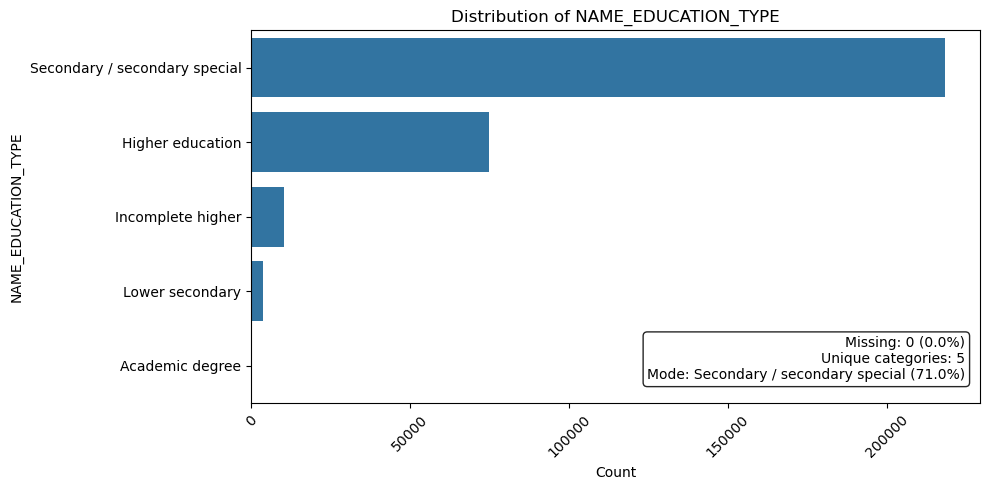

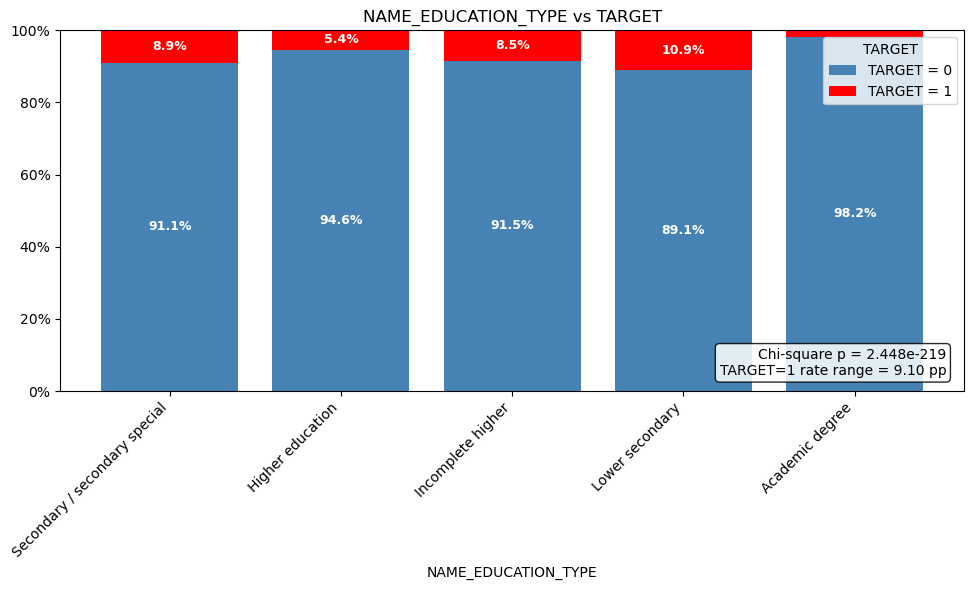

In [20]:
plot_categorical_distribution(df=app_df, cat_var='NAME_EDUCATION_TYPE')
plot_categorical_vs_binary(df=app_df, cat_var='NAME_EDUCATION_TYPE', target_var='TARGET')

Academic degree will be merged with higher education since they have the lowest default rate and have similar educational profile.

In [21]:
app_df['NAME_EDUCATION_TYPE_grouped'] = np.where(
    app_df['NAME_EDUCATION_TYPE'].isin(['Higher education', 'Academic degree']),
    'Higher education / Academic degree',
    app_df['NAME_EDUCATION_TYPE']
)
app_df['NAME_EDUCATION_TYPE_grouped'].value_counts()

NAME_EDUCATION_TYPE_grouped
Secondary / secondary special         218391
Higher education / Academic degree     75027
Incomplete higher                      10277
Lower secondary                         3816
Name: count, dtype: int64

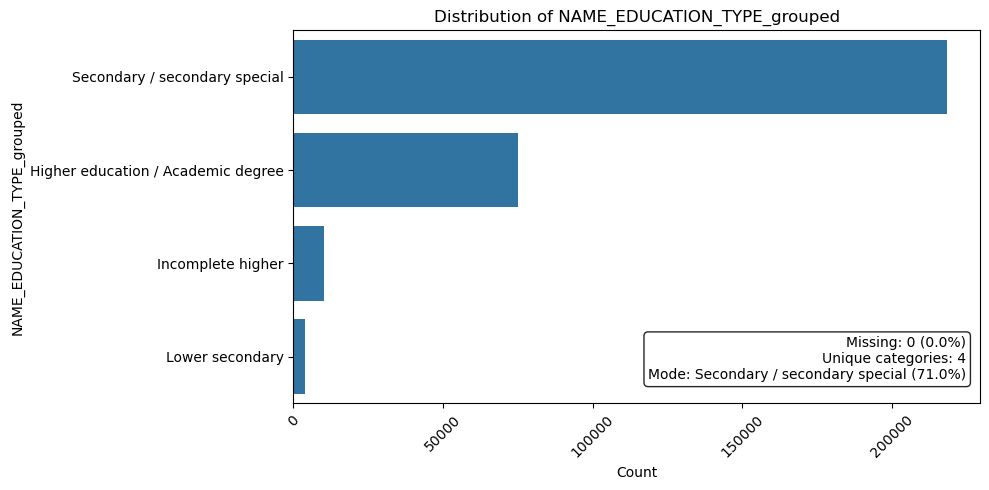

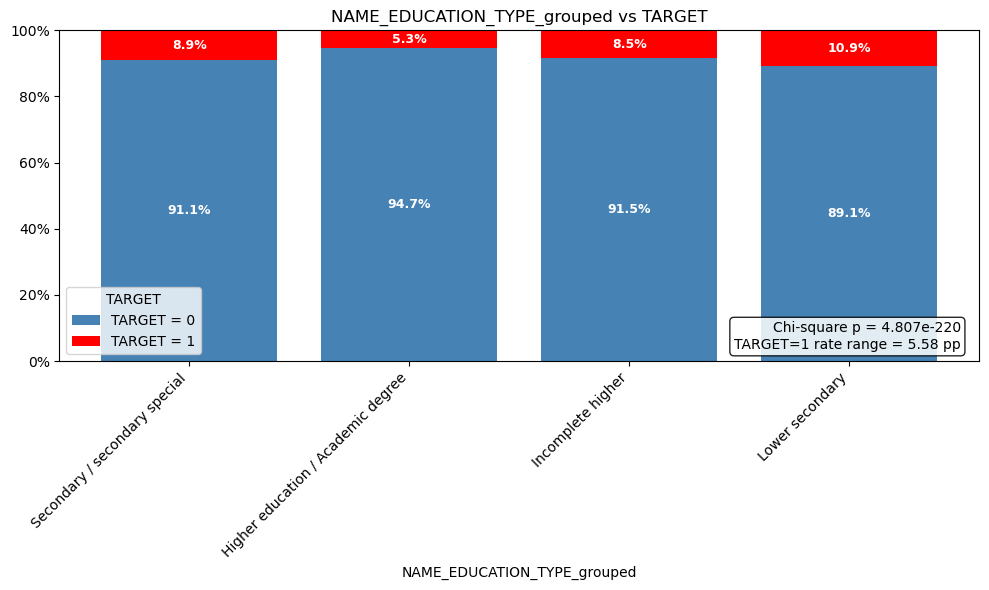

In [22]:
plot_categorical_distribution(df=app_df, cat_var='NAME_EDUCATION_TYPE_grouped')
plot_categorical_vs_binary(df=app_df, cat_var='NAME_EDUCATION_TYPE_grouped', target_var='TARGET')

Risk ratio differs accross categories. The variable willl be used in modeling

## 7. OCCUPATION_TYPE
What kind of occupation does the client have

In [23]:
app_df['OCCUPATION_TYPE'].value_counts()

OCCUPATION_TYPE
Laborers                 55186
Sales staff              32102
Core staff               27570
Managers                 21371
Drivers                  18603
High skill tech staff    11380
Accountants               9813
Medicine staff            8537
Security staff            6721
Cooking staff             5946
Cleaning staff            4653
Private service staff     2652
Low-skill Laborers        2093
Waiters/barmen staff      1348
Secretaries               1305
Realty agents              751
HR staff                   563
IT staff                   526
Name: count, dtype: int64

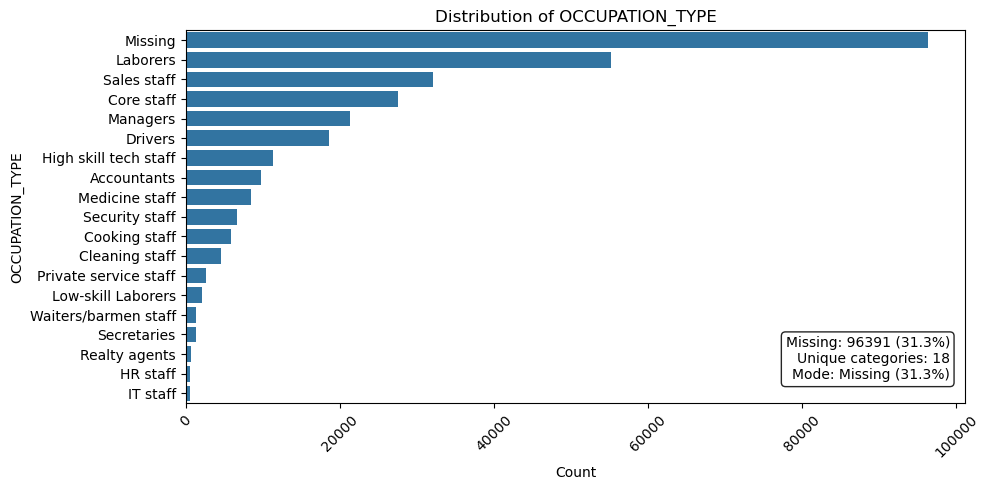

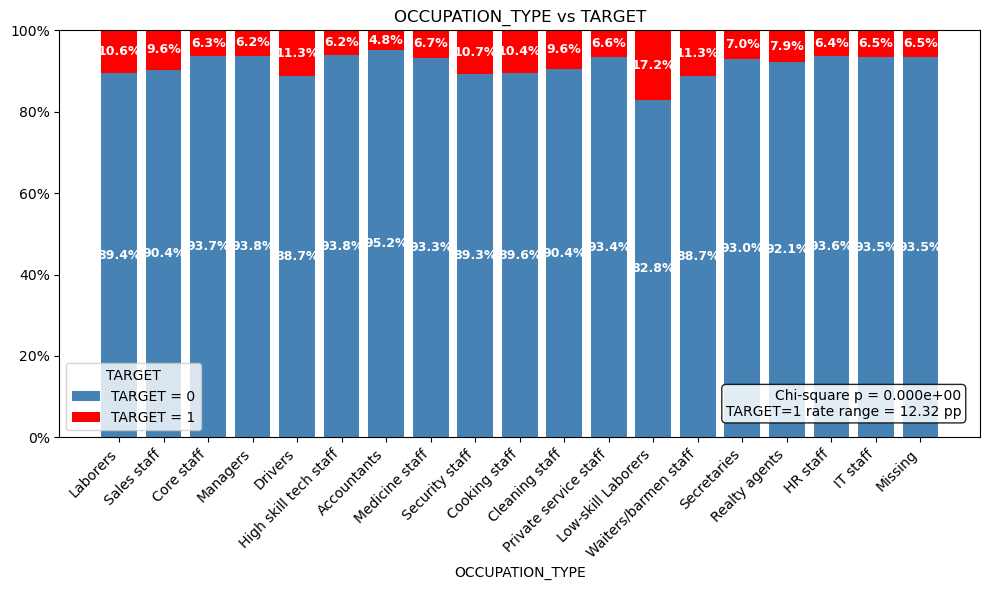

In [24]:
plot_categorical_distribution(df=app_df, cat_var='OCCUPATION_TYPE')
plot_categorical_vs_binary(df=app_df, cat_var='OCCUPATION_TYPE', target_var='TARGET')

Some categores will be grouped accoridng to risk level or/and business logic.

In [25]:
app_df['OCCUPATION_TYPE'].unique()

array(['Laborers', 'Core staff', 'Accountants', 'Managers', nan,
       'Drivers', 'Sales staff', 'Cleaning staff', 'Cooking staff',
       'Private service staff', 'Medicine staff', 'Security staff',
       'High skill tech staff', 'Waiters/barmen staff',
       'Low-skill Laborers', 'Realty agents', 'Secretaries', 'IT staff',
       'HR staff'], dtype=object)

In [26]:
app_df['OCCUPATION_TYPE_grouped'] = np.where(
    app_df['OCCUPATION_TYPE'].isin(['Core staff', 'Managers', 'High skill tech staff', 'IT staff']),
    'Core / Managers Hihg skill tech / IT',
    np.where(
        app_df['OCCUPATION_TYPE'].isin(['HR staff', 'Realty agents', 'Secretaries']),
        'HR / Realty agents / Secretaries',
        np.where(
            app_df['OCCUPATION_TYPE'].isin(['Waiters/barmen staff', 'Security staff', 'Laborers', 'Cooking staff']),
            'Waiters/barmen / Security / Laborers / Cooking',
            np.where(
                app_df['OCCUPATION_TYPE'].isin(['Private service staff', 'Medicine staff']),
                'Private service / Medicine staff',
                np.where(
                    app_df['OCCUPATION_TYPE'].isin(['Sales staff', 'Cleaning staff']),
                    'Sales staff / Cleaning staff',
                    app_df['OCCUPATION_TYPE']
                )
            )
        )
    )
)
app_df['OCCUPATION_TYPE_grouped'].value_counts()

OCCUPATION_TYPE_grouped
Waiters/barmen / Security / Laborers / Cooking    69201
Core / Managers Hihg skill tech / IT              60847
Sales staff / Cleaning staff                      36755
Drivers                                           18603
Private service / Medicine staff                  11189
Accountants                                        9813
HR / Realty agents / Secretaries                   2619
Low-skill Laborers                                 2093
Name: count, dtype: int64

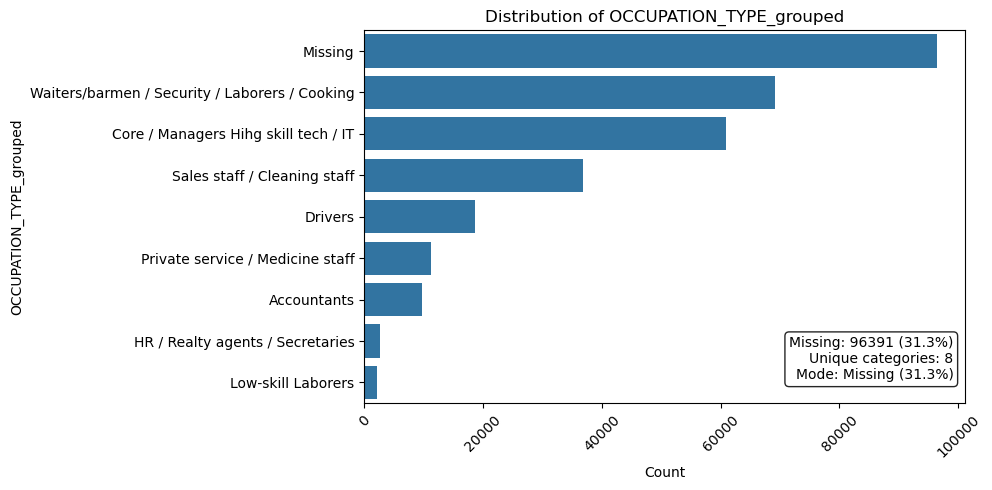

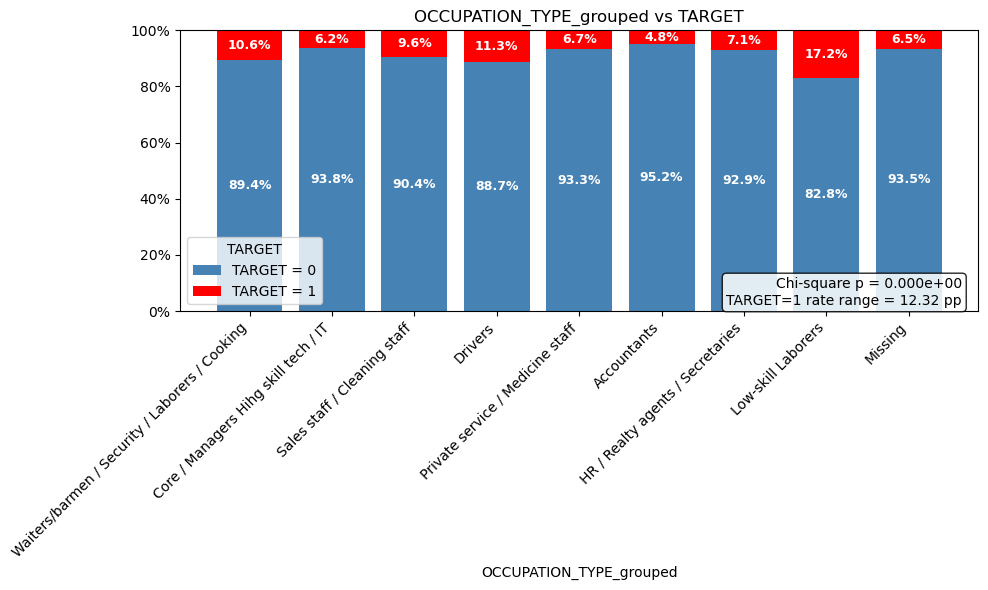

In [27]:
plot_categorical_distribution(df=app_df, cat_var='OCCUPATION_TYPE_grouped')
plot_categorical_vs_binary(df=app_df, cat_var='OCCUPATION_TYPE_grouped', target_var='TARGET')

The risk ratio differs accross categories. The variable should be used in modeling.

## 8. ORGANIZATION_TYPE
Type of organization where client works

In [28]:
app_df['ORGANIZATION_TYPE'].value_counts()

ORGANIZATION_TYPE
Business Entity Type 3    67992
XNA                       55374
Self-employed             38412
Other                     16683
Medicine                  11193
Business Entity Type 2    10553
Government                10404
School                     8893
Trade: type 7              7831
Kindergarten               6880
Construction               6721
Business Entity Type 1     5984
Transport: type 4          5398
Trade: type 3              3492
Industry: type 9           3368
Industry: type 3           3278
Security                   3247
Housing                    2958
Industry: type 11          2704
Military                   2634
Bank                       2507
Agriculture                2454
Police                     2341
Transport: type 2          2204
Postal                     2157
Security Ministries        1974
Trade: type 2              1900
Restaurant                 1811
Services                   1575
University                 1327
Industry: type 7      

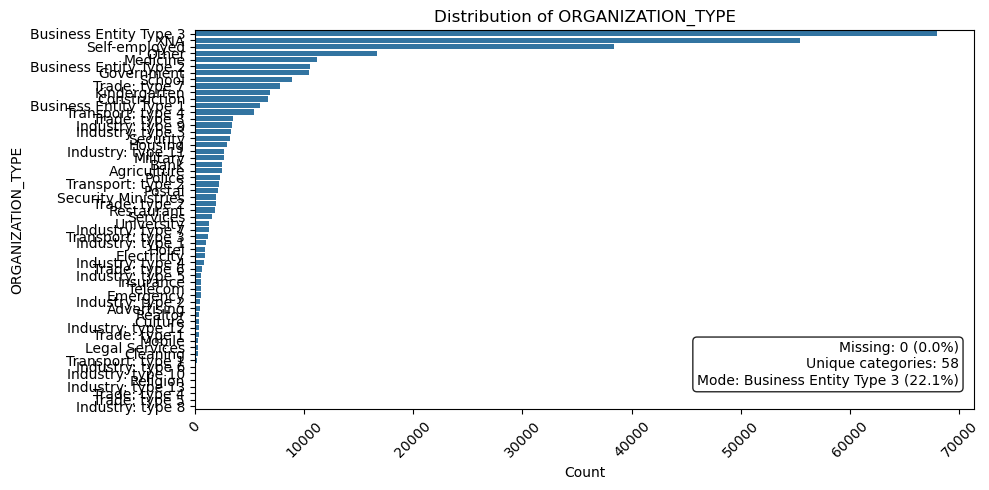

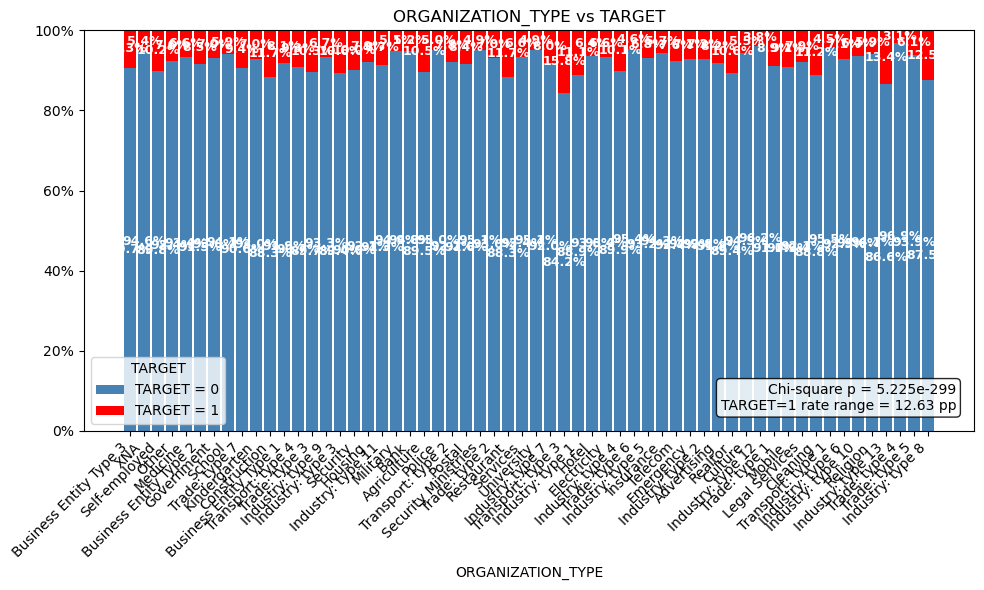

In [29]:
plot_categorical_distribution(df=app_df, cat_var='ORGANIZATION_TYPE')
plot_categorical_vs_binary(df=app_df, cat_var='ORGANIZATION_TYPE', target_var='TARGET')

In [30]:
app_df['ORGANIZATION_TYPE_grouped'] = np.where(
    app_df['ORGANIZATION_TYPE'].str.contains(pat='Industry'),
    'Industry',
    np.where(
        app_df['ORGANIZATION_TYPE'].str.contains(pat='Trade'),
        'Trade',
        np.where(
            app_df['ORGANIZATION_TYPE'].str.contains(pat='Business'),
            'Business',
            np.where(
                app_df['ORGANIZATION_TYPE'].str.contains(pat='Transport'),
                'Transport',
                app_df['ORGANIZATION_TYPE']
            )
        )
    )
)
app_df['ORGANIZATION_TYPE_grouped'].value_counts()

ORGANIZATION_TYPE_grouped
Business               84529
XNA                    55374
Self-employed          38412
Other                  16683
Trade                  14315
Industry               14311
Medicine               11193
Government             10404
Transport               8990
School                  8893
Kindergarten            6880
Construction            6721
Security                3247
Housing                 2958
Military                2634
Bank                    2507
Agriculture             2454
Police                  2341
Postal                  2157
Security Ministries     1974
Restaurant              1811
Services                1575
University              1327
Hotel                    966
Electricity              950
Insurance                597
Telecom                  577
Emergency                560
Advertising              429
Realtor                  396
Culture                  379
Mobile                   317
Legal Services           305
Cleaning         

In [31]:
cat_summary = categorical_target_summary(
    df=app_df,
    cat_var="ORGANIZATION_TYPE_grouped",
    target_var="TARGET",
    include_missing=True
)

cat_summary

,category,category_count,category_share,target_0_count,target_1_count,target_0_share,target_1_share
0,Business,84529,0.274881,76819,7710,0.908789,0.091211
1,XNA,55374,0.180072,52384,2990,0.946004,0.053996
2,Self-employed,38412,0.124913,34504,3908,0.898261,0.101739
3,Other,16683,0.054252,15408,1275,0.923575,0.076425
4,Trade,14315,0.046551,13016,1299,0.909256,0.090744
5,Industry,14311,0.046538,13080,1231,0.913982,0.086018
6,Medicine,11193,0.036399,10456,737,0.934155,0.065845
7,Government,10404,0.033833,9678,726,0.930219,0.069781
8,Transport,8990,0.029235,8121,869,0.903337,0.096663
9,School,8893,0.028919,8367,526,0.940852,0.059148


We will combine all categories that are accounted for less than 1% of observations.

In [51]:
minor_categories = cat_summary[cat_summary['category_share'] < 0.01]['category'].values
np.append(minor_categories, 'Other')

array(['Housing', 'Military', 'Bank', 'Agriculture', 'Police', 'Postal',
       'Security Ministries', 'Restaurant', 'Services', 'University',
       'Hotel', 'Electricity', 'Insurance', 'Telecom', 'Emergency',
       'Advertising', 'Realtor', 'Culture', 'Mobile', 'Legal Services',
       'Cleaning', 'Religion', 'Other'], dtype=object)

In [58]:
app_df['ORGANIZATION_TYPE_grouped'] = np.where(
    app_df['ORGANIZATION_TYPE'].str.contains(pat='Industry'),
    'Industry',
    np.where(
        app_df['ORGANIZATION_TYPE'].str.contains(pat='Trade'),
        'Trade',
        np.where(
            app_df['ORGANIZATION_TYPE'].str.contains(pat='Business'),
            'Business',
            np.where(
                app_df['ORGANIZATION_TYPE'].str.contains(pat='Transport'),
                'Transport',
                np.where(
                    app_df['ORGANIZATION_TYPE'].isin(np.append(minor_categories, 'Other')),
                    'Other',
                    np.where(
                        app_df['ORGANIZATION_TYPE'].isin(['Business', 'Trade']),
                        'Business / Trade',
                        np.where(
                            app_df['ORGANIZATION_TYPE'].isin(['Self-employed', 'Security', 'Transport']),
                            'Self-employed / Security / Transport',
                            np.where(
                                app_df['ORGANIZATION_TYPE'].isin(['Other', 'Government']),
                                'Other / Governemnt',
                                app_df['ORGANIZATION_TYPE']
                            )
                        )
                    )
                )
            )
        )
    )
)
app_df['ORGANIZATION_TYPE_grouped'].value_counts()

ORGANIZATION_TYPE_grouped
Business                                84529
XNA                                     55374
Other                                   44242
Self-employed / Security / Transport    41659
Trade                                   14315
Industry                                14311
Medicine                                11193
Other / Governemnt                      10404
Transport                                8990
School                                   8893
Kindergarten                             6880
Construction                             6721
Name: count, dtype: int64

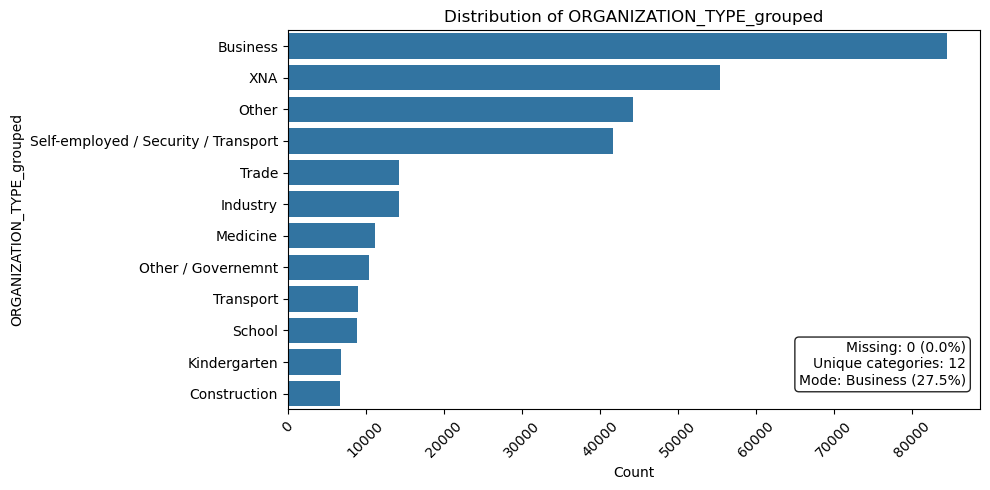

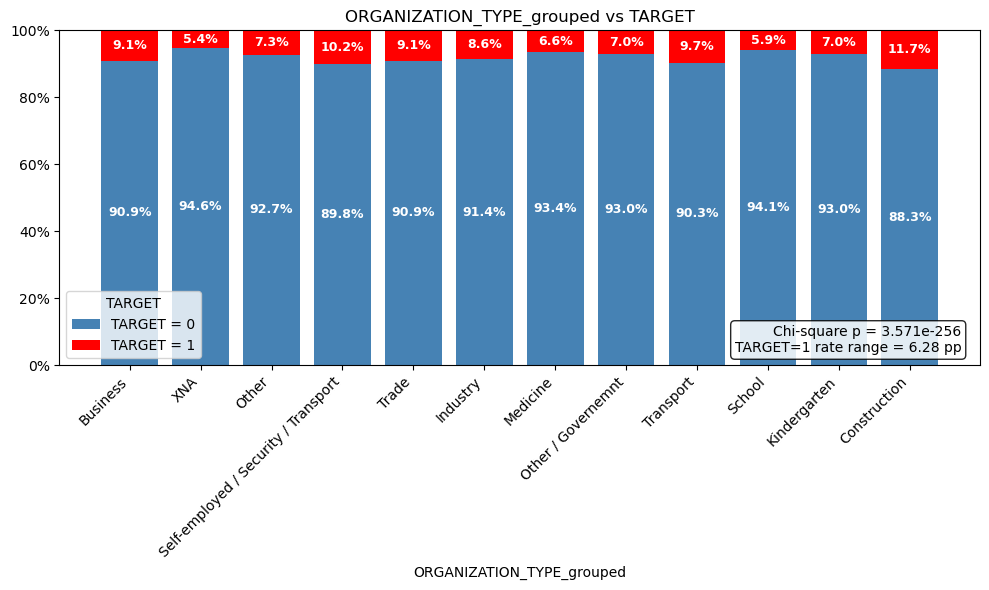

In [59]:
plot_categorical_distribution(df=app_df, cat_var='ORGANIZATION_TYPE_grouped')
plot_categorical_vs_binary(df=app_df, cat_var='ORGANIZATION_TYPE_grouped', target_var='TARGET')

Default ratio differs accross categories. It should be used in modeling.

## 9. REG_REGION_NOT_LIVE_REGION
Flag if client's permanent address does not match contact address (1=different, 0=same, at region level)

In [60]:
app_df['REG_REGION_NOT_LIVE_REGION'].value_counts()

REG_REGION_NOT_LIVE_REGION
0    302854
1      4657
Name: count, dtype: int64

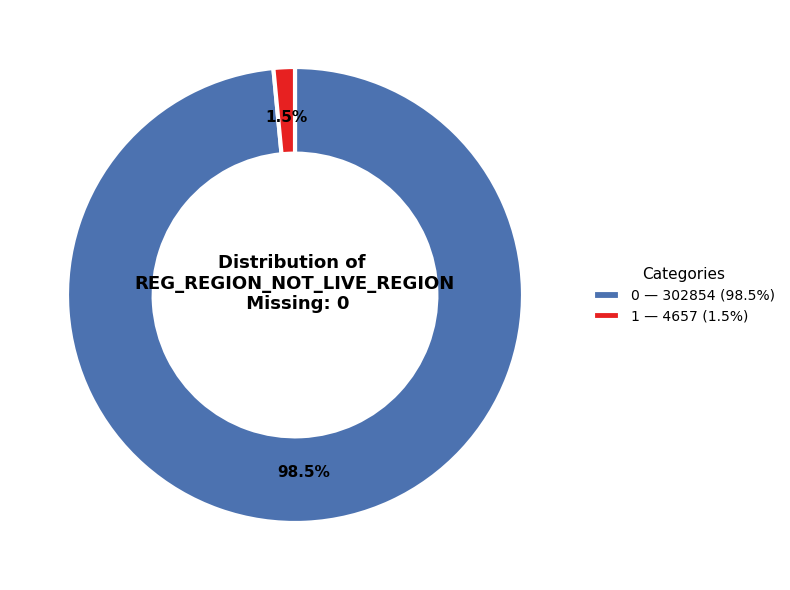

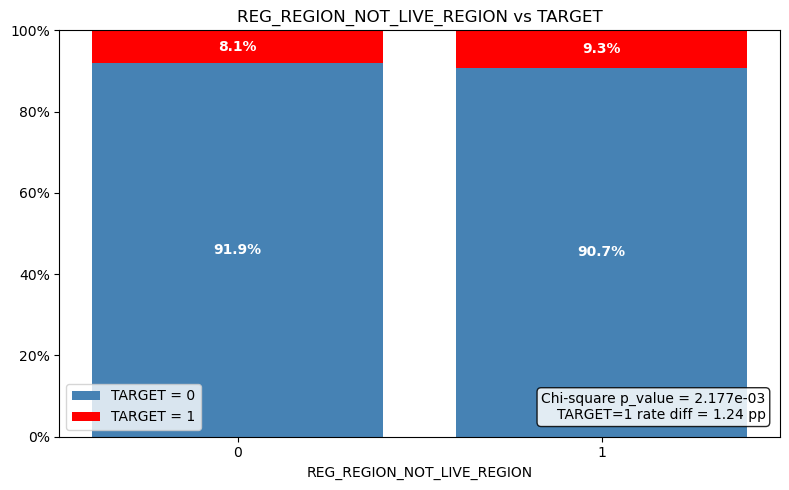

In [61]:
plot_binary_distribution(df=app_df, binary_var='REG_REGION_NOT_LIVE_REGION')
plot_binary_vs_binary(df=app_df, binary_var='REG_REGION_NOT_LIVE_REGION', target_var='TARGET')

This variable holds strong signal for dafault prediction. It will be used in modeling.

## 10. REG_REGION_NOT_WORK_REGION
Flag if client's permanent address does not match work address (1=different, 0=same, at region level)

In [62]:
app_df['REG_REGION_NOT_WORK_REGION'].value_counts()

REG_REGION_NOT_WORK_REGION
0    291899
1     15612
Name: count, dtype: int64

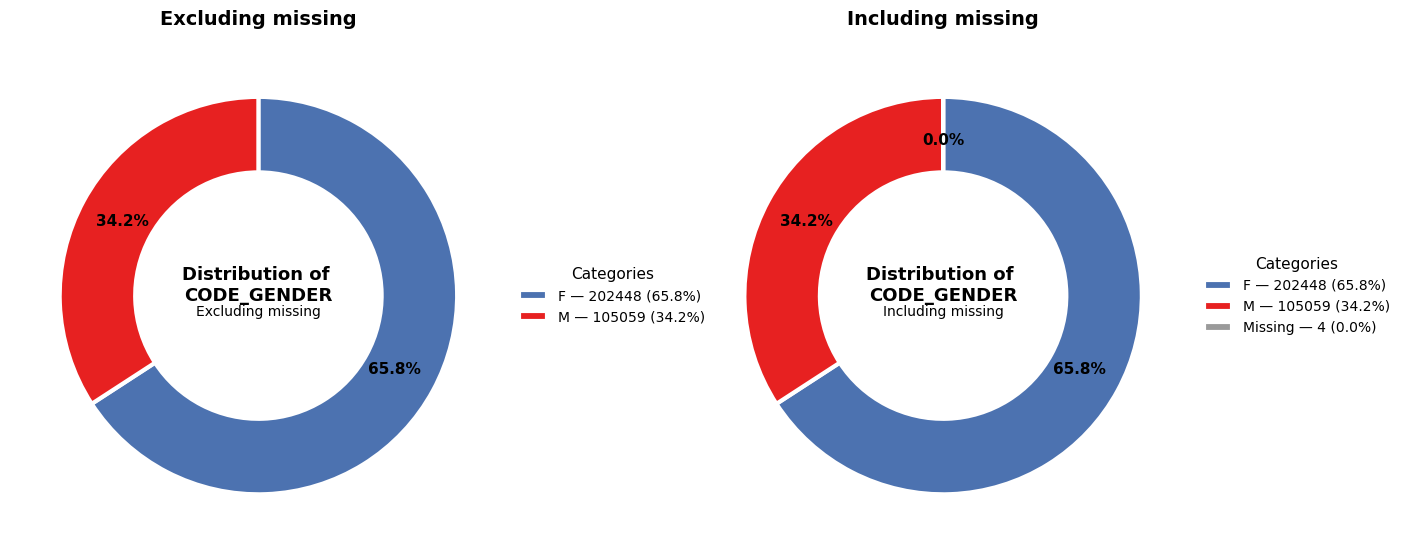

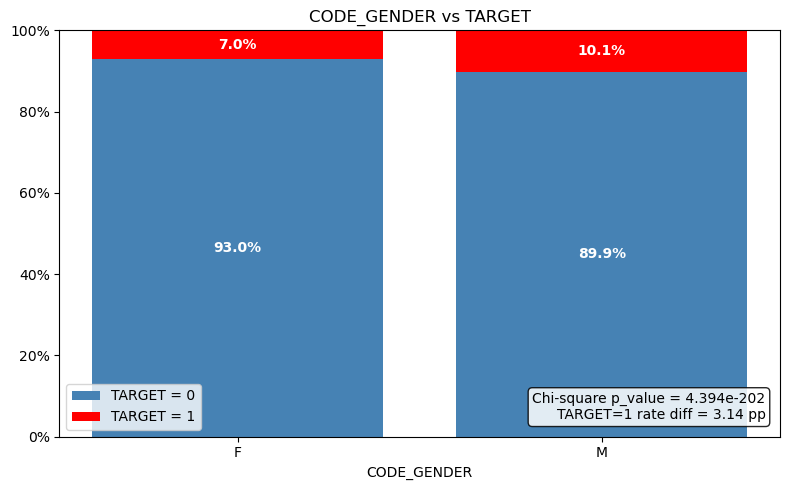

In [35]:
plot_binary_distribution(df=app_df, binary_var='CODE_GENDER')
plot_binary_vs_binary(df=app_df, binary_var='CODE_GENDER', target_var='TARGET')

This variable holds strong signal for dafault prediction. It will be used in modeling.

## 11. LIVE_REGION_NOT_WORK_REGION
Flag if client's contact address does not match work address (1=different, 0=same, at region level)

In [63]:
app_df['LIVE_REGION_NOT_WORK_REGION'].value_counts()

LIVE_REGION_NOT_WORK_REGION
0    295008
1     12503
Name: count, dtype: int64

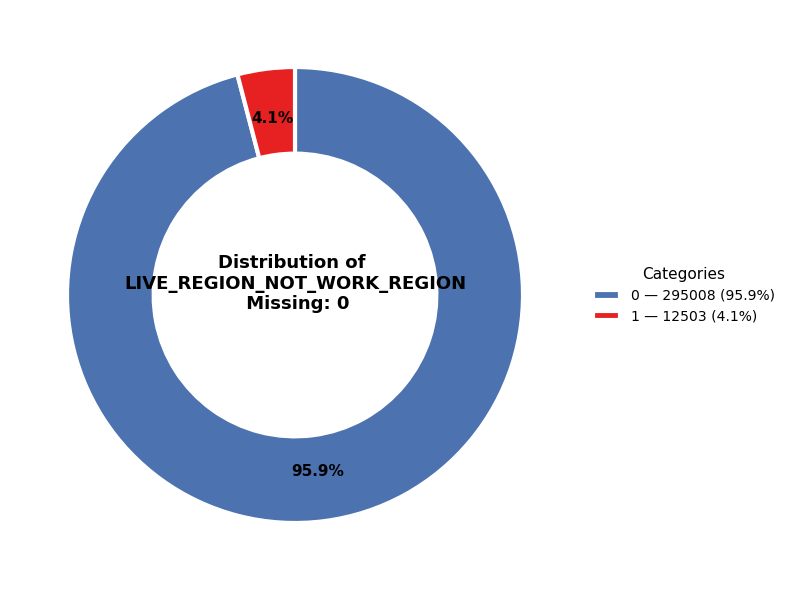

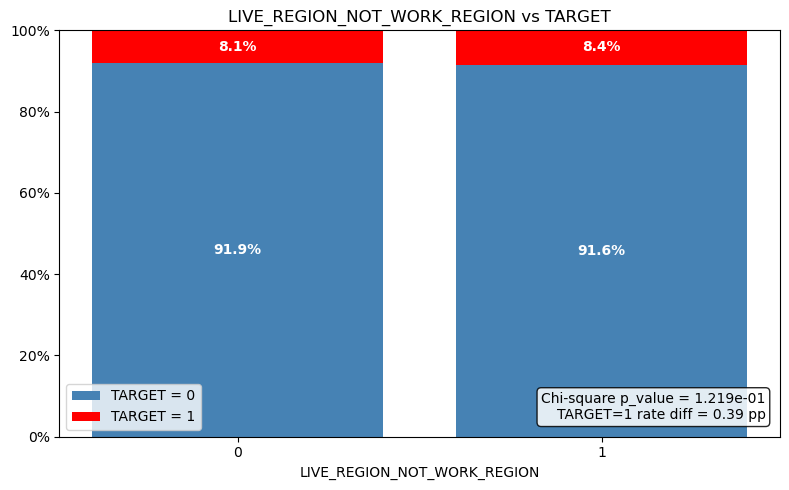

In [65]:
plot_binary_distribution(df=app_df, binary_var='LIVE_REGION_NOT_WORK_REGION')
plot_binary_vs_binary(df=app_df, binary_var='LIVE_REGION_NOT_WORK_REGION', target_var='TARGET')

The risk share is almost equal, and the difference is not statistically significant. It shouldn't be used in modeling.

## 12. REG_CITY_NOT_LIVE_CITY 
Flag if client's permanent address does not match contact address (1=different, 0=same, at city level)

In [66]:
app_df['REG_CITY_NOT_LIVE_CITY'].value_counts()

REG_CITY_NOT_LIVE_CITY
0    283472
1     24039
Name: count, dtype: int64

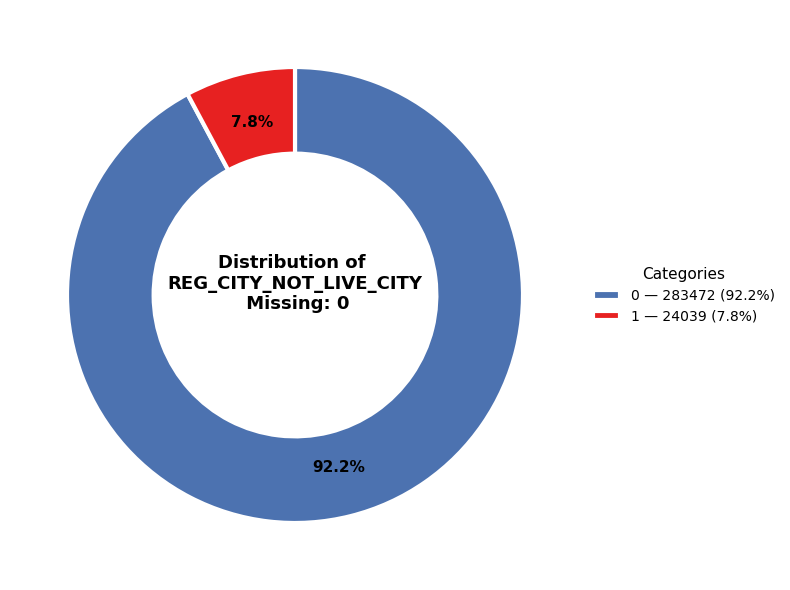

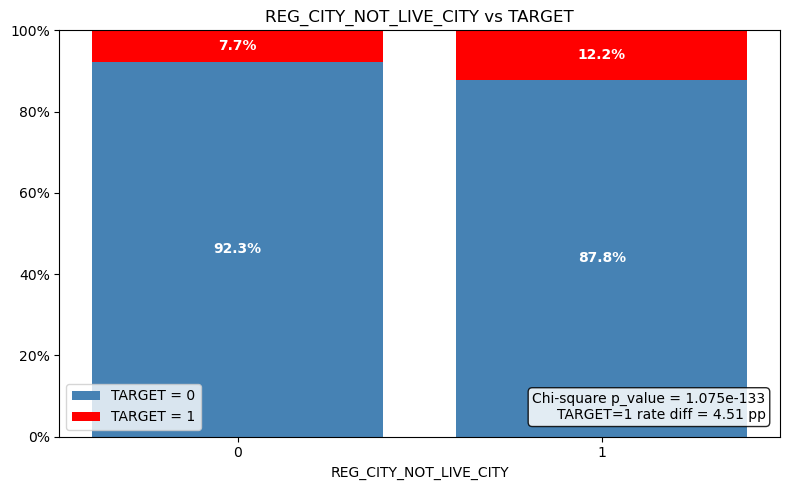

In [67]:
plot_binary_distribution(df=app_df, binary_var='REG_CITY_NOT_LIVE_CITY')
plot_binary_vs_binary(df=app_df, binary_var='REG_CITY_NOT_LIVE_CITY', target_var='TARGET')

The difference in distributions is statistically significant. The variable probably holds important information. It should be used in modeling.

## 13. REG_CITY_NOT_WORK_CITY
Flag if client's permanent address does not match work address (1=different, 0=same, at city level)

In [68]:
app_df['REG_CITY_NOT_WORK_CITY'].value_counts()

REG_CITY_NOT_WORK_CITY
0    236644
1     70867
Name: count, dtype: int64

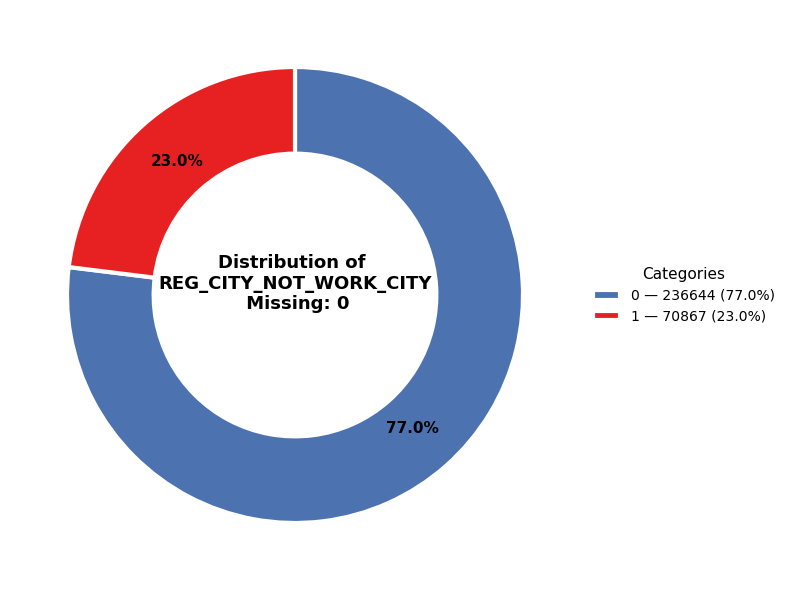

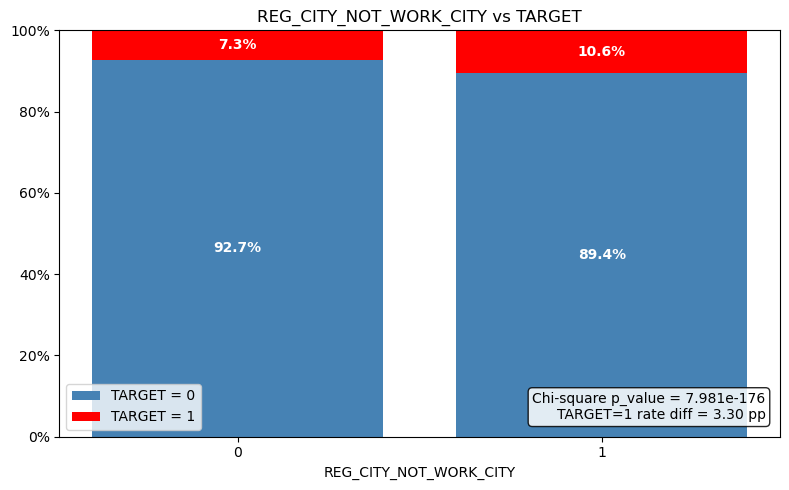

In [69]:
plot_binary_distribution(df=app_df, binary_var='REG_CITY_NOT_WORK_CITY')
plot_binary_vs_binary(df=app_df, binary_var='REG_CITY_NOT_WORK_CITY', target_var='TARGET')

The variable probably holds important information. It should be used in modeling.

## 14. LIVE_CITY_NOT_WORK_CITY
Flag if client's contact address does not match work address (1=different, 0=same, at city level)

In [70]:
app_df['LIVE_CITY_NOT_WORK_CITY'].value_counts()

LIVE_CITY_NOT_WORK_CITY
0    252296
1     55215
Name: count, dtype: int64

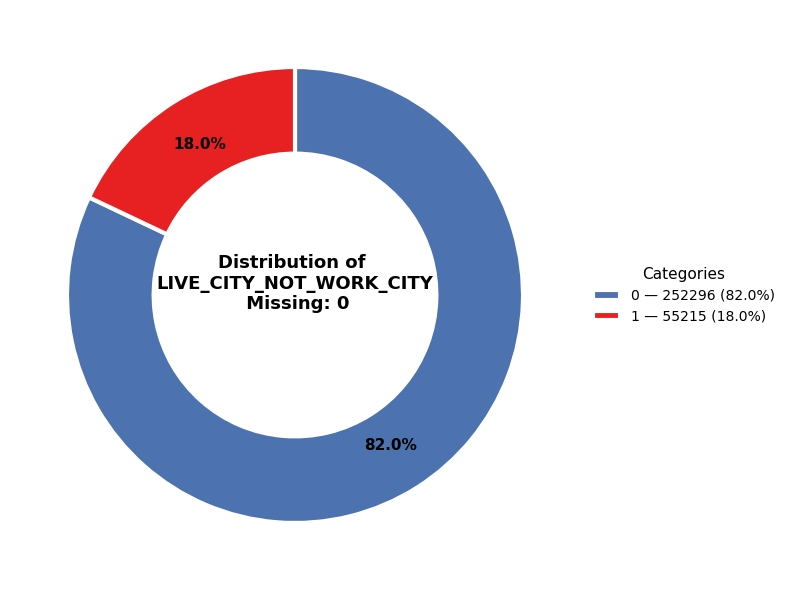

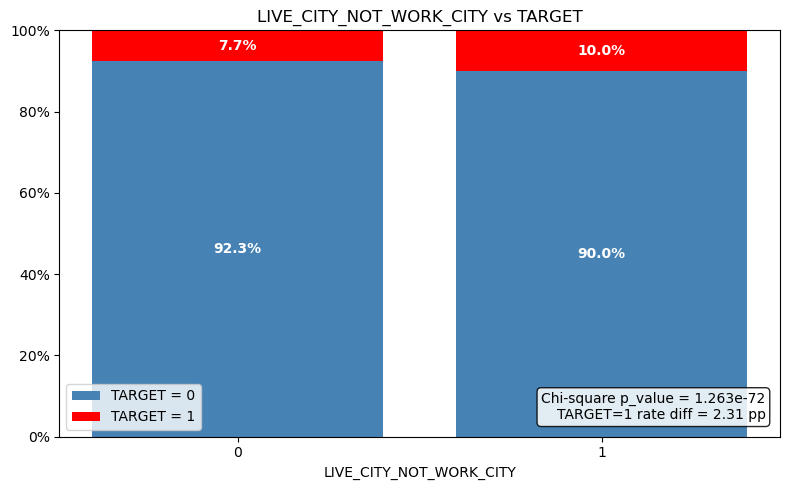

In [71]:
plot_binary_distribution(df=app_df, binary_var='LIVE_CITY_NOT_WORK_CITY')
plot_binary_vs_binary(df=app_df, binary_var='LIVE_CITY_NOT_WORK_CITY', target_var='TARGET')

The variable probably holds important information. It should be used in modeling.

## 15. Application financial and material summary
Variables that should be used as predictors
- CODE_GENDER (drop missing values.)
- DAYS_BIRTH
- CNT_CHILDREN_grouped
- CNT_FAM_MEMBERS_grouped
- NAME_FAMILY_STATUS_grouped
- NAME_EDUCATION_TYPE_grouped
- OCCUPATION_TYPE_grouped
- ORGANIZATION_TYPE_grouped
- REG_REGION_NOT_LIVE_REGION
- REG_CITY_NOT_LIVE_CITY
- REG_CITY_NOT_WORK_CITY
- LIVE_CITY_NOT_WORK_CITY